In [66]:
import numpy as np
import pandas as pd
import sklearn
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df=pd.read_csv("all_tickets_processed_improved_v3.csv")

In [70]:
df.head(100)

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous
...,...,...
95,new purchase po hello received ex po please ad...,Purchase
96,access to upload and modify documents on uploa...,HR Support
97,admin account access level level hi needed pri...,Access
98,access password reset hi germany he tried hims...,Access


In [69]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [62]:
print(df["Topic_group"].value_counts())

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
X = df["Document"]
y = df["Topic_group"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )),
    ("clf", LinearSVC())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8514841137123745

Classification Report:

                       precision    recall  f1-score   support

               Access       0.91      0.89      0.90      1455
Administrative rights       0.82      0.74      0.78       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.82      0.86      0.84      2760
     Internal Project       0.87      0.82      0.85       451
        Miscellaneous       0.81      0.82      0.82      1400
             Purchase       0.95      0.90      0.92       497
              Storage       0.92      0.87      0.89       556

             accuracy                           0.85      9568
            macro avg       0.87      0.84      0.86      9568
         weighted avg       0.85      0.85      0.85      9568



In [64]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

In [65]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(pipeline.named_steps["clf"].classes_)

['Access' 'Administrative rights' 'HR Support' 'Hardware'
 'Internal Project' 'Miscellaneous' 'Purchase' 'Storage']


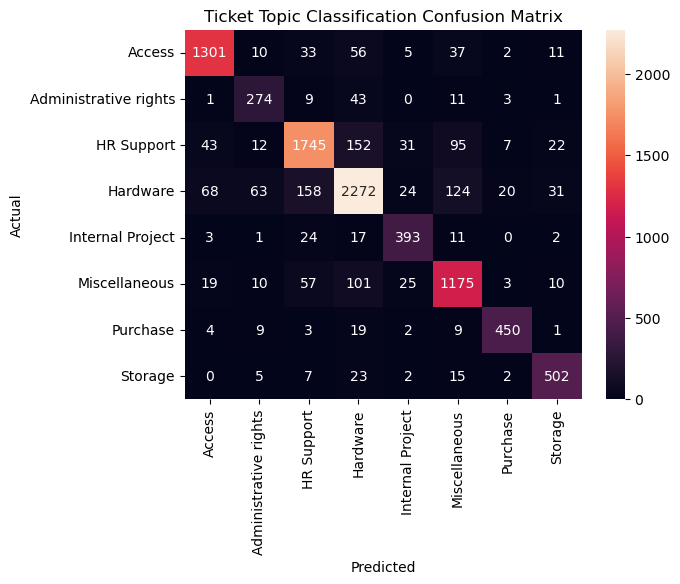

In [71]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

labels = sorted(y.unique())

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Ticket Topic Classification Confusion Matrix")
plt.show()


In [72]:
urgent_keywords = [
    "urgent", "asap", "immediately", "critical",
    "system down", "not working", "failure",
    "cannot access", "error", "blocked"
]

In [73]:
def assign_priority(text, predicted_topic):
    text_lower = text.lower()
    
    urgency_score = 0
    
    for word in urgent_keywords:
        if word in text_lower:
            urgency_score += 1
    
    # Base priority from topic
    if predicted_topic in ["Hardware", "Access"]:
        base_priority = 2
    elif predicted_topic in ["HR Support", "Administrative rights"]:
        base_priority = 1
    else:
        base_priority = 0
    
    total_score = urgency_score + base_priority
    
    if total_score >= 3:
        return "High"
    elif total_score == 2:
        return "Medium"
    else:
        return "Low"


In [74]:
sample_texts = X_test.sample(5, random_state=42)

for text in sample_texts:
    topic = pipeline.predict([text])[0]
    priority = assign_priority(text, topic)
    
    print("Ticket:", text[:150])
    print("Predicted Topic:", topic)
    print("Predicted Priority:", priority)
    print("-" * 60)


Ticket: validation rules tuesday pm validation rules importance high hi please call thank kind regards engineer tuesday validation rules importance high hi cu
Predicted Topic: Hardware
Predicted Priority: High
------------------------------------------------------------
Ticket: cannot access la one sa sa one merge si sa sa search everything tot si cum sa merge super pot la weekend la rare analyst ext hub sent thursday hi guys
Predicted Topic: Hardware
Predicted Priority: High
------------------------------------------------------------
Ticket: re new old re old normal cutie please log thank re old care care carton regards developer re old re old bun cum si legate care ca pot si monitor care 
Predicted Topic: Hardware
Predicted Priority: Medium
------------------------------------------------------------
Ticket: oracle list expense reports pm expense reports hi how submitted approved expense reports looked over after approved
Predicted Topic: Miscellaneous
Predicted Priority: Low
------